# Task 1
Побудуйте модель поліноміальної регресії для однієї ознаки на базі датасету California Housing:
* Завантажте датасет fetch_california_housing.
* Використовуйте тільки одну ознаку MedInc.
* Створіть поліноміальні ознаки ступеня 2 за допомогою PolynomialFeatures.
* Розділіть дані на навчальну і тестову вибірки (80/20, random_state=42).
* Навчіть модель і обчисліть R² на тестовій вибірці.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score
from IPython.display import Markdown as md

In [7]:
california = fetch_california_housing(as_frame=True)
X = california.frame[['MedInc']]
y = california.frame['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

poly_2 = PolynomialFeatures(degree=2)
X_train_poly2 = poly_2.fit_transform(X_train)
X_test_poly2 = poly_2.transform(X_test)

model_2 = LinearRegression()
model_2.fit(X_train_poly2, y_train)

y_pred_2 = model_2.predict(X_test_poly2)
r2_2 = r2_score(y_test, y_pred_2)

md("|Model|Degree|Test R²|\n|-|-|-|\n|Polynomial Regression|2|%f|\n" % (r2_2))

|Model|Degree|Test R²|
|-|-|-|
|Polynomial Regression|2|0.463318|


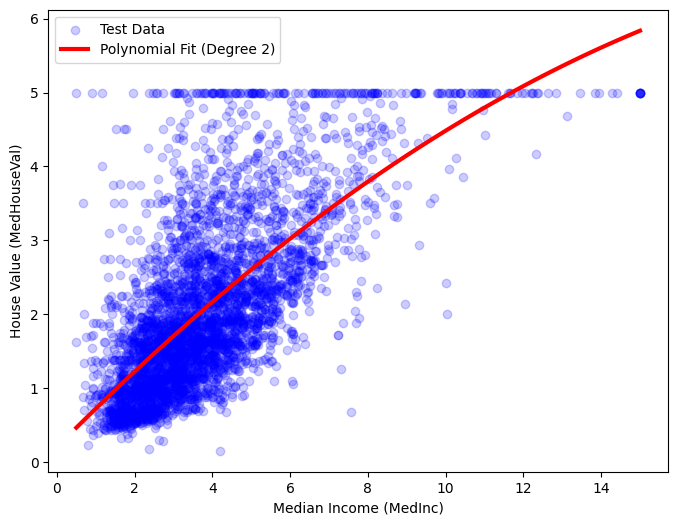

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(X_test, y_test, alpha=0.2, color='blue', label='Test Data')

x_range = np.linspace(X['MedInc'].min(), X['MedInc'].max(), 100).reshape(-1, 1)
x_range_df = pd.DataFrame(x_range, columns=['MedInc'])
x_range_poly = poly_2.transform(x_range_df)
y_range_pred = model_2.predict(x_range_poly)

ax.plot(x_range, y_range_pred, color='red', linewidth=3, label='Polynomial Fit (Degree 2)')

ax.set_xlabel('Median Income (MedInc)')
ax.set_ylabel('House Value (MedHouseVal)')
ax.legend()
plt.show()

# Task 2
Перевірте, як ступінь полінома впливає на якість моделі:
* Використовуйте ознаку MedInc з California Housing.
* Побудуйте моделі з PolynomialFeatures ступенів 1, 2 і 3.
* Для кожної моделі обчисліть R² на train і test.
* Запишіть результати в таблицю:

In [11]:
degrees = [1, 2, 3]
results = []
models = {}
polys = {}

for d in degrees:
    poly = PolynomialFeatures(degree=d)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    train_r2 = r2_score(y_train, model.predict(X_train_poly))
    test_r2 = r2_score(y_test, model.predict(X_test_poly))
    
    results.append((d, train_r2, test_r2))
    models[d] = model
    polys[d] = poly

table = "|Polynomial Degree|Train R²|Test R²|\n|-|-|-|\n"
for res in results:
    table += "|%d|%f|%f|\n" % (res[0], res[1], res[2])
md(table)

|Polynomial Degree|Train R²|Test R²|
|-|-|-|
|1|0.476993|0.458859|
|2|0.481598|0.463318|
|3|0.490806|0.467116|


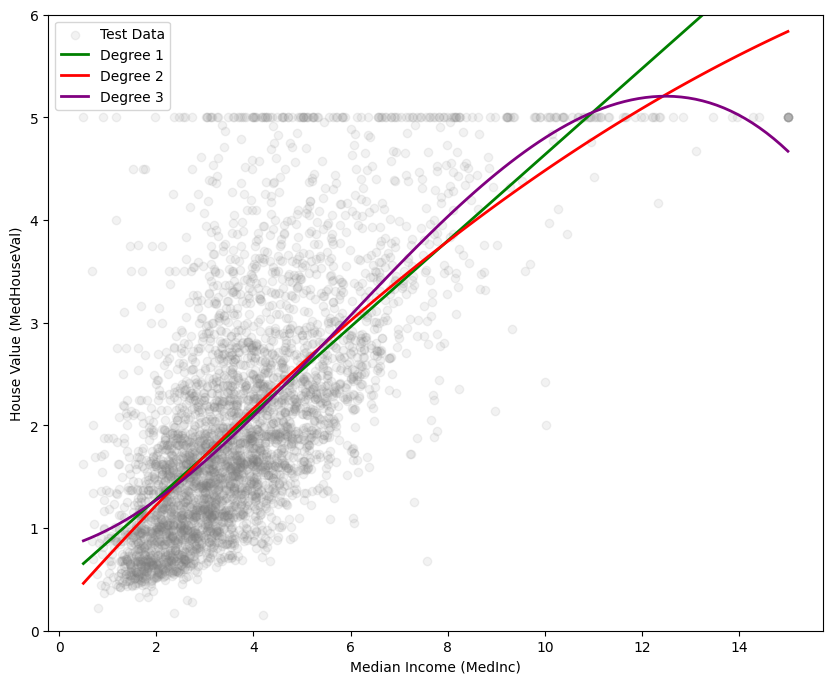

In [12]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(X_test, y_test, alpha=0.1, color='gray', label='Test Data')

x_range = np.linspace(X['MedInc'].min(), X['MedInc'].max(), 100).reshape(-1, 1)
x_range_df = pd.DataFrame(x_range, columns=['MedInc'])

colors = ['green', 'red', 'purple']

for d, color in zip(degrees, colors):
    y_range_pred = models[d].predict(polys[d].transform(x_range_df))
    ax.plot(x_range, y_range_pred, color=color, linewidth=2, label=f'Degree {d}')

ax.set_xlabel('Median Income (MedInc)')
ax.set_ylabel('House Value (MedHouseVal)')
ax.set_ylim(0, 6)
ax.legend()

plt.show()